# Exploratory Data Analysis (EDA)

In this notebook, we explore historical sales and inventory data to understand
how demand behaves across SKUs, categories, and time.

The goal is not to create as many plots as possible, but to extract insights
that will guide forecasting and inventory decisions later.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [5]:
import sys
sys.path.append('../')

# Load processed data
from src.utils import load_processed_data

sales_df, inventory_df, products_df, suppliers_df = load_processed_data()

print("Processed data loaded successfully")

Processed data loaded successfully


In [7]:
# Convert date columns to datetime
sales_df["date"] = pd.to_datetime(sales_df["date"])

## Dataset Preparation for Analysis

We combine sales data with product attributes to enable category-level
and SKU-level analysis.

In [8]:
# Merge sales data with product details
sales_enriched = sales_df.merge(
    products_df,
    on="sku_id",
    how="left"
)

sales_enriched.head()

,date,sku_id,units_sold,selling_price,gross_revenue,promo_flag,discount_pct,month,week_of_year,day_of_week,is_weekend,is_festival_month,is_payday_period,season_tag,holiday_flag,weather_index,campaign_intensity,platform_traffic_source,traffic_index,competitor_price_index,competitor_stockout_flag,bundle_offer_flag,stock_visibility_score,rating_score,review_volume,product_visibility_rank,sku_name,category,sub_category,mrp,cost_price,supplier_id
0,2024-01-01,SKU0001,28,1028.54,28799.12,0,0.0072,1,1,0,0,0,1,winter,0,1.033050,1,affiliate,1.028220,1.039897,0,0,0.332970,4.99,220,14,NovaCharge Cable,Electronics Accessories,Audio,1036,731.48,SUP003
1,2024-01-02,SKU0001,27,942.76,25454.52,0,0.0900,1,1,1,0,0,1,winter,0,1.075864,0,organic,1.000124,1.034213,0,0,0.332574,4.99,220,26,NovaCharge Cable,Electronics Accessories,Audio,1036,731.48,SUP003
2,2024-01-03,SKU0001,27,1023.78,27642.06,0,0.0118,1,1,2,0,0,1,winter,0,0.776739,0,paid,1.042157,1.019800,0,0,0.369938,4.99,220,50,NovaCharge Cable,Electronics Accessories,Audio,1036,731.48,SUP003
3,2024-01-04,SKU0001,29,940.90,27286.10,0,0.0918,1,1,3,0,0,1,winter,0,1.029230,0,paid,0.998036,1.004657,0,0,0.445269,4.99,220,42,NovaCharge Cable,Electronics Accessories,Audio,1036,731.48,SUP003
4,2024-01-05,SKU0001,37,812.43,30059.91,1,0.2158,1,1,4,0,0,1,winter,0,1.093677,1,organic,1.047220,0.956571,0,0,0.414885,4.99,220,20,NovaCharge Cable,Electronics Accessories,Audio,1036,731.48,SUP003


## Overall Demand Trend

We start by understanding how total demand behaves over time.
This helps identify seasonality, growth trends, and anomalies.

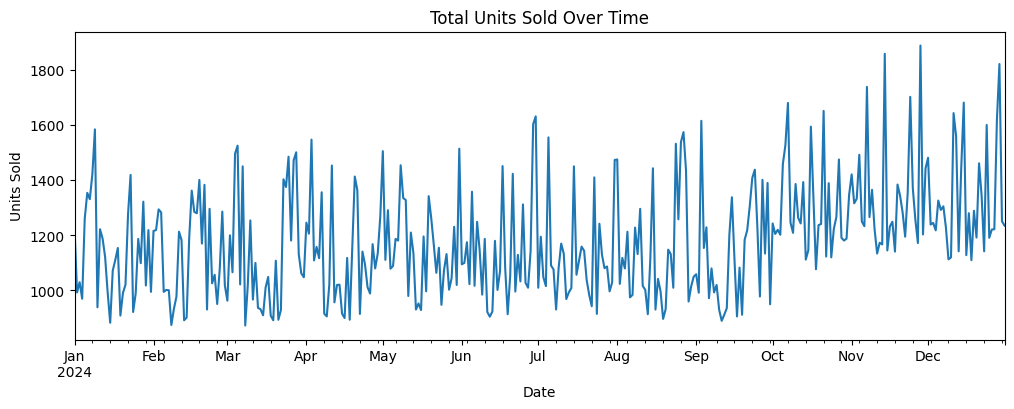

In [9]:
daily_demand = sales_enriched.groupby("date")["units_sold"].sum()

plt.figure(figsize=(12, 4))
daily_demand.plot()
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

## Category-Level Demand Patterns

Different categories behave very differently in terms of volume,
seasonality, and volatility.

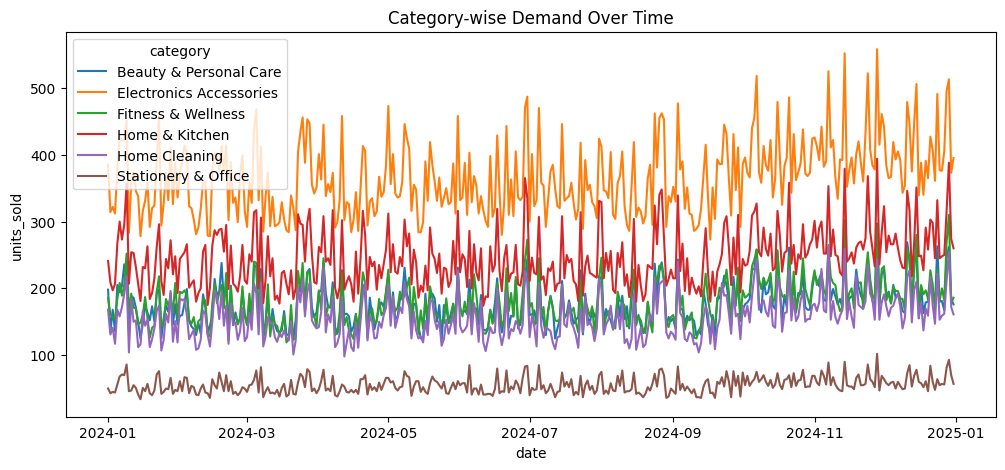

In [10]:
category_demand = (
    sales_enriched
    .groupby(["date", "category"])["units_sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=category_demand, x="date", y="units_sold", hue="category")
plt.title("Category-wise Demand Over Time")
plt.show()

## SKU Velocity Analysis

We identify fast-moving and slow-moving SKUs based on average weekly demand.

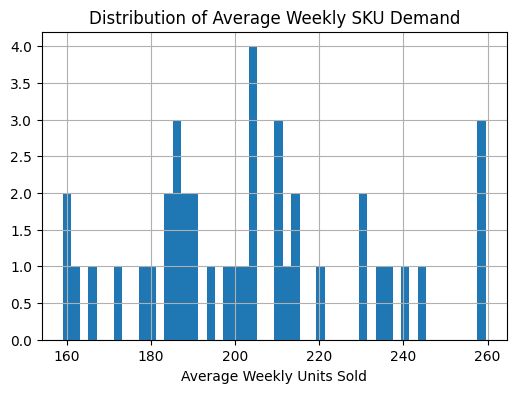

In [11]:
weekly_sales = (
    sales_enriched
    .set_index("date")
    .groupby("sku_id")["units_sold"]
    .resample("W")
    .sum()
    .reset_index()
)

sku_velocity = weekly_sales.groupby("sku_id")["units_sold"].mean()

plt.figure(figsize=(6, 4))
sku_velocity.hist(bins=50)
plt.title("Distribution of Average Weekly SKU Demand")
plt.xlabel("Average Weekly Units Sold")
plt.show()

## Revenue Concentration (Pareto Insight)

A small percentage of SKUs usually contributes to the majority of sales.
This insight motivates ABC classification later.

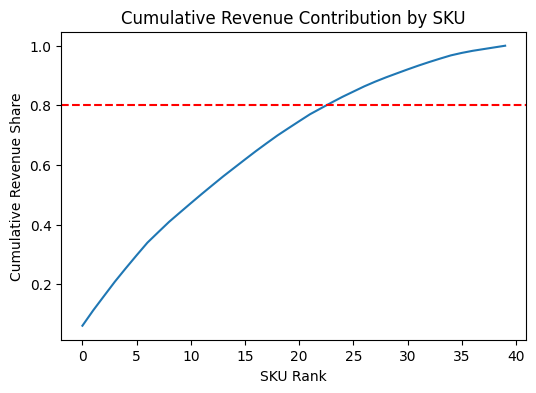

In [12]:
sales_enriched["revenue"] = (
    sales_enriched["units_sold"] * sales_enriched["selling_price"]
)

sku_revenue = (
    sales_enriched
    .groupby("sku_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

cumulative_revenue = sku_revenue.cumsum() / sku_revenue.sum()

plt.figure(figsize=(6, 4))
cumulative_revenue.reset_index(drop=True).plot()
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Cumulative Revenue Contribution by SKU")
plt.xlabel("SKU Rank")
plt.ylabel("Cumulative Revenue Share")
plt.show()

## Demand Volatility Analysis

High demand volatility increases forecast uncertainty and
requires higher safety stock.

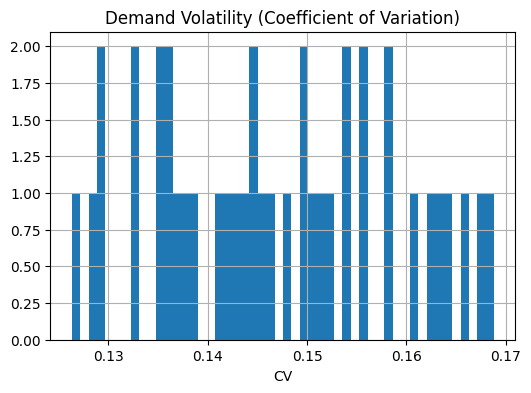

In [13]:
sku_volatility = (
    weekly_sales
    .groupby("sku_id")["units_sold"]
    .agg(["mean", "std"])
)

sku_volatility["cv"] = sku_volatility["std"] / sku_volatility["mean"]

plt.figure(figsize=(6, 4))
sku_volatility["cv"].hist(bins=50)
plt.title("Demand Volatility (Coefficient of Variation)")
plt.xlabel("CV")
plt.show()

## Stockout Signal Exploration

We approximate stockout situations by identifying periods where
inventory levels hit zero.

In [16]:
stockout_events = inventory_df[inventory_df["current_stock"] == 0]

stockout_counts = (
    stockout_events
    .groupby("sku_id")
    .size()
    .sort_values(ascending=False)
)

stockout_counts.head()

Series([], dtype: int64)

## Supplier Lead Time Variability

Lead time uncertainty directly affects reorder point and safety stock.

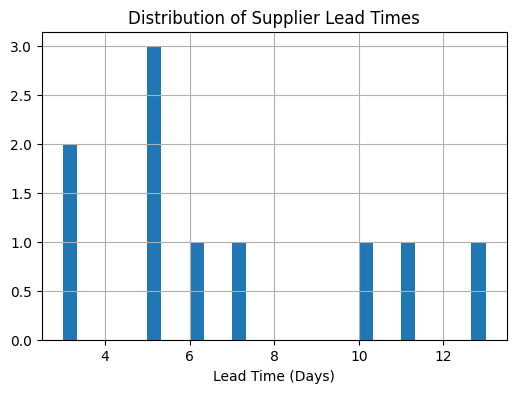

In [19]:
plt.figure(figsize=(6, 4))
suppliers_df["avg_lead_time"].hist(bins=30)
plt.title("Distribution of Supplier Lead Times")
plt.xlabel("Lead Time (Days)")
plt.show()

## Key Takeaways from EDA

- Demand is highly skewed across SKUs
- Different categories exhibit different seasonality and volatility
- A small number of SKUs drive most revenue
- Many SKUs show high demand variability
- Supplier lead times vary widely and add replenishment risk

These insights justify:
- SKU segmentation (ABC/XYZ)
- Segment-specific forecasting models
- Variable safety stock policies